## 3. 多模型评估与对比

> **学习目标**：掌握模型评估的完整流程——准确率计算、分类报告（Precision/Recall/F1）、混淆矩阵可视化、错误样本分析。

---

### 什么是模型评估？

训练完模型后，我们需要在**未见过的测试集**上评估其真实表现。评估不仅是看"准确率"，更重要的是：

| 指标 | 含义 | 问题 |
|------|------|------|
| **Accuracy（准确率）** | 预测正确的比例 | 类别不平衡时可能误导 |
| **Precision（精确率）** | 预测为某类中真正是该类的比例 | 误报了多少？ |
| **Recall（召回率）** | 某类样本中被正确找出的比例 | 漏掉了多少？ |
| **F1-Score** | Precision 和 Recall 的调和平均 | 综合衡量 |
| **Confusion Matrix（混淆矩阵）** | 每类预测结果的分布矩阵 | 模型最容易混淆哪些类？ |

### 本 Notebook 做了什么？

```
测试集 (10000张)
    │
    ├─→ MLP    ─→ 准确率 + 分类报告 + 混淆矩阵
    ├─→ CNN    ─→ 准确率 + 分类报告 + 混淆矩阵
    ├─→ ResNet ─→ 准确率 + 分类报告 + 混淆矩阵  ─→ 横向对比表
    ├─→ ViT    ─→ 准确率 + 分类报告 + 混淆矩阵
    └─→ LSTM   ─→ 准确率 + 分类报告 + 混淆矩阵
                                    │
                              错误样本可视化
```

> **前置条件**：需要先运行对应的训练 notebook（02/05/06/07/08），确保 `models/` 目录下有权重文件。

## 1. 加载训练好的模型

> 自动加载 MLP / CNN / ResNet / ViT / LSTM 五种模型的预训练权重，跳过未训练的模型。

In [1]:
# [1. 导入依赖] seaborn:热力图 | sklearn:classification_report + confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import fetch_openml
import warnings
warnings.filterwarnings('ignore')

# ==== 中文字体配置 ====
# matplotlib 默认不支持中文，需手动指定支持中文的字体
# 优先级：微软雅黑 > 黑体 > DejaVu Sans（英文回退）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ======= 超参数集中修改区 =======
BATCH_SIZE = 256          # 测试批次大小（不影响结果，只影响速度）

# 选择要评估的模型（注释/删除来开关）：
EVAL_MODELS = [
    'mlp',
    'cnn',
    'resnet',
    'vit',
    'lstm',
]

# 模型注册表：统一管理路径、构建参数
# 修改模型结构请在这里改 create 中的参数（如 hidden_dims、num_blocks 等）
MODEL_CONFIG = {
    'mlp': {
        'name': 'MLP',
        'path': '../models/mlp/best.pth',
        'input_type': 'flat',
        'create': lambda: MLP(input_dim=784, hidden_dims=[1024, 256],
                              num_classes=10, dropout=0.2).to(device)
    },
    'cnn': {
        'name': 'CNN',
        'path': '../models/cnn/best.pth',
        'input_type': 'image',
        'create': lambda: SimpleCNN(num_classes=10, dropout=0.3).to(device)
    },
    'resnet': {
        'name': 'ResNet',
        'path': '../models/resnet/best.pth',
        'input_type': 'image',
        'create': lambda: ResNet(BasicBlock, num_blocks=[2, 2, 2],
                                 num_classes=10).to(device)
    },
    'vit': {
        'name': 'ViT',
        'path': '../models/vit/best.pth',
        'input_type': 'image',
        'create': lambda: ViT(img_size=28, patch_size=4, in_channels=1,
                              num_classes=10, embed_dim=64, depth=4,
                              num_heads=4, mlp_ratio=2, dropout=0.1).to(device)
    },
    'lstm': {
        'name': 'LSTM',
        'path': '../models/lstm/best.pth',
        'input_type': 'sequence',
        'create': lambda: LSTMModel(input_dim=28, hidden_dim=128, num_layers=2,
                                    num_classes=10, dropout=0.3,
                                    bidirectional=True).to(device)
    }
}
# ================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'设备: {device}')

设备: cuda


In [2]:
# [1. 数据准备] 三种输入格式并行准备: flat(MLP用) / image(CNN/ResNet/ViT用) / sequence(LSTM用)
# 重新加载数据确保 notebook 可独立运行
mnist = fetch_openml(
    name="mnist_784", version=1, as_frame=False,
    cache=True, data_home="../data"
)
X = mnist.data.reshape(-1, 28, 28).astype(np.uint8)
y = mnist.target.astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# flat:   (N, 784)         — MLP 展平输入
# image:  (N, 1, 28, 28)   — CNN / ResNet / ViT 图像输入
# seq:    (N, 28, 28)      — LSTM 序列输入 (28时间步 × 28特征)
X_test_t_flat = torch.tensor(X_test.reshape(-1, 784), dtype=torch.float32) / 255.0
X_test_t_image = torch.tensor(X_test.reshape(-1, 1, 28, 28), dtype=torch.float32) / 255.0
X_test_t_seq = torch.tensor(X_test.astype(np.float32) / 255.0, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

test_loader_flat = DataLoader(TensorDataset(X_test_t_flat, y_test_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader_image = DataLoader(TensorDataset(X_test_t_image, y_test_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader_seq = DataLoader(TensorDataset(X_test_t_seq, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"测试集: {len(y_test)} 样本")
print(f"  展平格式 (MLP):            {X_test_t_flat.shape}")
print(f"  图像格式 (CNN/ResNet/ViT):  {X_test_t_image.shape}")
print(f"  序列格式 (LSTM):            {X_test_t_seq.shape}")

测试集: 10000 样本
  展平格式 (MLP):            torch.Size([10000, 784])
  图像格式 (CNN/ResNet/ViT):  torch.Size([10000, 1, 28, 28])
  序列格式 (LSTM):            torch.Size([10000, 28, 28])


In [5]:
# [1. 模型定义+加载] 五种模型类(结构与训练时完全一致) + MODEL_CONFIG注册表 + 自动加载权重

class MLP(nn.Module):
    """
    多层感知机

    Args:
        input_dim: 输入维度，MNIST 展平后为 784
        hidden_dims: 隐藏层维度列表，默认 [512, 256]
        num_classes: 分类数，MNIST 为 10
        dropout: Dropout 比率
    """
    def __init__(self, input_dim=784, hidden_dims=None, num_classes=10, dropout=0.2):
        super(MLP, self).__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256]
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        Args:
            x: (B, 784) 展平后的图像向量
        Returns:
            (B, 10) logits
        """
        return self.net(x)


class SimpleCNN(nn.Module):
    """
    可配置 CNN

    Args:
        num_classes: 分类数
        dropout: Dropout 比率
        conv_channels: 每层卷积通道数列表，默认 [32, 64]
        conv_per_block: 每块卷积层数
        kernel_size: 卷积核大小
        fc_hidden: 全连接隐藏层维度
        in_channels: 输入通道数
        input_size: 输入图像尺寸
    """
    def __init__(self, num_classes=10, dropout=0.3,
                 conv_channels=None, conv_per_block=2,
                 kernel_size=3, fc_hidden=128,
                 in_channels=1, input_size=28):
        super(SimpleCNN, self).__init__()
        if conv_channels is None:
            conv_channels = [32, 64]
        in_ch = in_channels
        self.conv_blocks = nn.ModuleList()
        for out_ch in conv_channels:
            layers = []
            for j in range(conv_per_block):
                layers.extend([
                    nn.Conv2d(in_ch if j == 0 else out_ch, out_ch,
                              kernel_size=kernel_size, padding=kernel_size // 2),
                    nn.BatchNorm2d(out_ch), nn.ReLU(),
                ])
            layers.extend([nn.MaxPool2d(2), nn.Dropout2d(dropout)])
            self.conv_blocks.append(nn.Sequential(*layers))
            in_ch = out_ch
        final_spatial = input_size // (2 ** len(conv_channels))
        flatten_dim = conv_channels[-1] * final_spatial * final_spatial
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, fc_hidden),
            nn.BatchNorm1d(fc_hidden), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes)
        )

    def forward(self, x):
        """
        Args:
            x: (B, 1, 28, 28) 图像
        Returns:
            (B, 10) logits
        """
        for block in self.conv_blocks:
            x = block(x)
        return self.classifier(x)


class BasicBlock(nn.Module):
    """
    ResNet 基础残差块

    主路: Conv → BN → ReLU → Conv → BN
    短路: 恒等映射 (或 1×1 卷积对齐维度)
    输出: ReLU(主路 + 短路)
    """
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) 输入特征图
        Returns:
            (B, C_out, H', W') 残差块输出
        """
        identity = self.shortcut(x)
        out = nn.ReLU()(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return nn.ReLU()(out)


class ResNet(nn.Module):
    """
    可配置 ResNet，专为小尺寸图像设计

    Args:
        block: 残差块类型（BasicBlock）
        num_blocks: 每层残差块数量，如 [2, 2, 2]
        num_classes: 分类数
        in_planes: 初始通道数
        channel_list: 每层通道数，如 [32, 64, 128]
    """
    def __init__(self, block, num_blocks, num_classes=10,
                 in_planes=32, channel_list=None):
        super(ResNet, self).__init__()
        if channel_list is None:
            channel_list = [32, 64, 128]
        self.in_channels = in_planes
        self.num_layers = len(channel_list)
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, in_planes, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(in_planes), nn.ReLU()
        )
        for i, (ch, nb) in enumerate(zip(channel_list, num_blocks)):
            stride = 1 if i == 0 else 2
            layer = self._make_layer(block, ch, nb, stride=stride)
            setattr(self, f'layer{i + 1}', layer)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(channel_list[-1], num_classes)
        # Kaiming 初始化
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """构建一个残差层（多个残差块堆叠）"""
        layers = [block(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(block(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 28, 28) 图像
        Returns:
            (B, 10) logits
        """
        x = self.conv1(x)
        for i in range(1, self.num_layers + 1):
            x = getattr(self, f'layer{i}')(x)
        x = self.avgpool(x)
        return self.fc(torch.flatten(x, 1))


class PatchEmbedding(nn.Module):
    """
    将图片切分为 patch 并用 Conv2d 做线性投影

    28×28 图像 → 4×4 patches → 49 个 patch
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=1, embed_dim=64):
        super(PatchEmbedding, self).__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        """
        Args:
            x: (B, C, H, W) 图像
        Returns:
            (B, num_patches, embed_dim) patch 序列
        """
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x


class ViT(nn.Module):
    """
    轻量 Vision Transformer

    28×28 → 4×4 patches(49个) → Transformer → 分类

    Args:
        img_size: 图像尺寸
        patch_size: patch 大小
        in_channels: 输入通道数
        num_classes: 分类数
        embed_dim: 嵌入维度
        depth: Transformer 层数
        num_heads: 多头注意力头数
        mlp_ratio: FFN 扩展比例
        dropout: Dropout 比率
    """
    def __init__(self, img_size=28, patch_size=4, in_channels=1,
                 num_classes=10, embed_dim=64, depth=4, num_heads=4,
                 mlp_ratio=2, dropout=0.1):
        super(ViT, self).__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth,
                                               enable_nested_tensor=False)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 28, 28) 图像
        Returns:
            (B, 10) logits
        """
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_drop(x + self.pos_embed)
        x = self.transformer(x)
        return self.head(self.norm(x[:, 0]))


class LSTMModel(nn.Module):
    """
    双向 LSTM

    28 时间步 × 28 特征 → hidden(128) × 2 层 → FC(64) → 10 类

    Args:
        input_dim: 每步输入特征维度
        hidden_dim: LSTM 隐状态维度
        num_layers: LSTM 层数
        num_classes: 分类数
        dropout: Dropout 比率
        bidirectional: 是否双向
    """
    def __init__(self, input_dim=28, hidden_dim=128, num_layers=2,
                 num_classes=10, dropout=0.3, bidirectional=True):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        fc_input_dim = hidden_dim * self.num_directions
        self.fc = nn.Sequential(
            nn.Linear(fc_input_dim, 64),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """
        Args:
            x: (B, 28, 28) 序列
        Returns:
            (B, 10) logits
        """
        lstm_out, (h_n, c_n) = self.lstm(x)
        if self.bidirectional:
            h_forward  = h_n[-2, :, :]   # 正向最后层隐状态
            h_backward = h_n[-1, :, :]   # 反向最后层隐状态
            h_last = torch.cat([h_forward, h_backward], dim=1)
        else:
            h_last = h_n[-1, :, :]
        return self.fc(self.dropout(h_last))

# 根据 EVAL_MODELS 筛选要加载的模型
active_config = {k: v for k, v in MODEL_CONFIG.items() if k in EVAL_MODELS}
print(f'准备评估: {list(active_config.keys())}')


# [1. 自动加载所有已训练模型权重] 遍历 active_config 逐一加载 | 跳过不存在的权重文件
import os

loaded_models = {}
model_loader_map = {
    'flat': test_loader_flat,
    'image': test_loader_image,
    'sequence': test_loader_seq,
}

sep = '=' * 70
print(sep)
pattern = '{:<8s} {:>10s}  {:<12s}  {}'
print(pattern.format('Model', 'Params', 'Status', 'Path'))
print(sep)

for key, cfg in active_config.items():
    path = cfg['path']
    name = cfg['name']
    if not os.path.exists(path):
        print(pattern.format(name, 'N/A', 'SKIP (no file)', path))
        continue
    try:
        model = cfg['create']()
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        loaded_models[key] = model
        p = sum(p.numel() for p in model.parameters())
        print(pattern.format(name, f'{p:,}', 'LOADED', path))
    except Exception as e:
        print(pattern.format(name, 'N/A', 'FAIL', str(e)))

print(sep)

if not loaded_models:
    raise RuntimeError('没有加载到任何模型！请先运行对应的训练 notebook。')
else:
    print(f'\n已加载 {len(loaded_models)} 个模型: {list(loaded_models.keys())}')

Model        Params  Status        Path
MLP       1,071,370  LOADED        ../models/mlp/best.pth

已加载 1 个模型: ['mlp']


## 2. 测试集整体评估

> 对所有已加载模型执行完整测试集评估，输出每个类别的 Precision / Recall / F1。

### 评估流程

```
model.eval() + torch.no_grad()
    │
    └─→ 遍历测试集 DataLoader
        ├─→ 前向传播: outputs = model(images)
        ├─→ 取最大值: preds = argmax(outputs)
        └─→ 收集: preds + labels
                │
            └─→ 计算: accuracy = (preds == labels).mean()
                └─→ sklearn: classification_report(preds, labels)
```

**关键概念**：
- `model.eval()`: 关闭 Dropout/BatchNorm 的训练模式
- `torch.no_grad()`: 不计算梯度，节省显存和加速推理
- `classification_report`: 自动计算每个类别的 Precision/Recall/F1

In [6]:
# [2. 评估所有模型] evaluate_model() → 准确率 + 预测/标签数组 | classification_report 各类别详细指标
def evaluate_model(model, loader, device):
    """
    评估单个模型在测试集上的表现

    Args:
        model: 已加载权重的 PyTorch 模型（已调用 model.eval()）
        loader: 测试集 DataLoader
        device: 'cuda' 或 'cpu'

    Returns:
        accuracy: float, 整体准确率
        preds_array: np.ndarray, 所有预测标签
        labels_array: np.ndarray, 所有真实标签
    """
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()
    return acc, all_preds, all_labels


# [2. 执行评估] 遍历所有已加载模型 | 输出准确率 + 参数量对比
eval_results = {}
print()
print('=' * 80)
fmt = '{:<8s} {:>12s}  {:>12s}'
print(fmt.format('Model', 'Accuracy', 'Parameters'))
print('=' * 80)

for key, model in loaded_models.items():
    cfg = MODEL_CONFIG[key]
    loader = model_loader_map[cfg['input_type']]
    acc, preds, labels = evaluate_model(model, loader, device)
    eval_results[key] = {'acc': acc, 'preds': preds, 'labels': labels}
    params = sum(p.numel() for p in model.parameters())
    print(fmt.format(cfg['name'], f'{acc:.4f}', f'{params:,}'))

print('=' * 80)

# [2. 每个模型详细分类报告] Precision / Recall / F1-Score 逐类别展示
for key, model in loaded_models.items():
    cfg = MODEL_CONFIG[key]
    r = eval_results[key]
    print()
    print('-' * 60)
    print(f"[{cfg['name']}] 测试集准确率: {r['acc']:.4f}")
    print('-' * 60)
    print(classification_report(r['labels'], r['preds'], digits=4))


Model        Accuracy    Parameters
MLP            0.9851     1,071,370

------------------------------------------------------------
[MLP] 测试集准确率: 0.9851
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9858    0.9929    0.9893       980
           1     0.9886    0.9956    0.9921      1135
           2     0.9864    0.9816    0.9840      1032
           3     0.9756    0.9881    0.9818      1010
           4     0.9847    0.9857    0.9852       982
           5     0.9909    0.9731    0.9819       892
           6     0.9896    0.9896    0.9896       958
           7     0.9835    0.9835    0.9835      1028
           8     0.9836    0.9836    0.9836       974
           9     0.9830    0.9752    0.9791      1009

    accuracy                         0.9851     10000
   macro avg     0.9852    0.9849    0.9850     10000
weighted avg     0.9851    0.9851    0.9851     10000



## 3. 模型对比汇总

> 一张表看清所有模型的 Accuracy、参数量、错误数。

### 如何解读？

- **Accuracy**: 越高越好，但需结合参数量看性价比
- **Params**: 参数量越大，模型越复杂，推理越慢
- **Errors**: 错误数越少越好，可以进一步分析错误原因

> 通常 CNN/ResNet > MLP ≈ ViT ≈ LSTM（在 MNIST 上）

In [7]:
# [3. 对比汇总] Accuracy / Params / Errors 三列横向对比
fmt = '{:<8s} {:>10s}  {:>10s}  {:>8s}'
print(fmt.format('Model', 'Accuracy', 'Params', 'Errors'))
print('-' * 44)
for key in loaded_models:
    cfg = MODEL_CONFIG[key]
    r = eval_results[key]
    err_count = (r['preds'] != r['labels']).sum()
    params = sum(p.numel() for p in loaded_models[key].parameters())
    print(fmt.format(cfg['name'], f"{r['acc']:.4f}", f'{params:,}', str(err_count)))

Model      Accuracy      Params    Errors
--------------------------------------------
MLP          0.9851   1,071,370       149


## 4. 混淆矩阵（所有模型）

> 行 = 真实标签，列 = 预测标签。对角线越亮，模型越准。

### 什么是混淆矩阵？

混淆矩阵是一个 N×N 的矩阵（N=类别数），其中：
- **第 i 行第 j 列** = 真实类别为 i，被预测为类别 j 的样本数
- **对角线** = 正确分类的样本数（越多越好）
- **非对角线** = 错误分类的样本（揭示模型容易混淆哪些类别）

例如：如果数字 "4" 经常被预测为 "9"，说明模型觉得这两个数字形态相似。

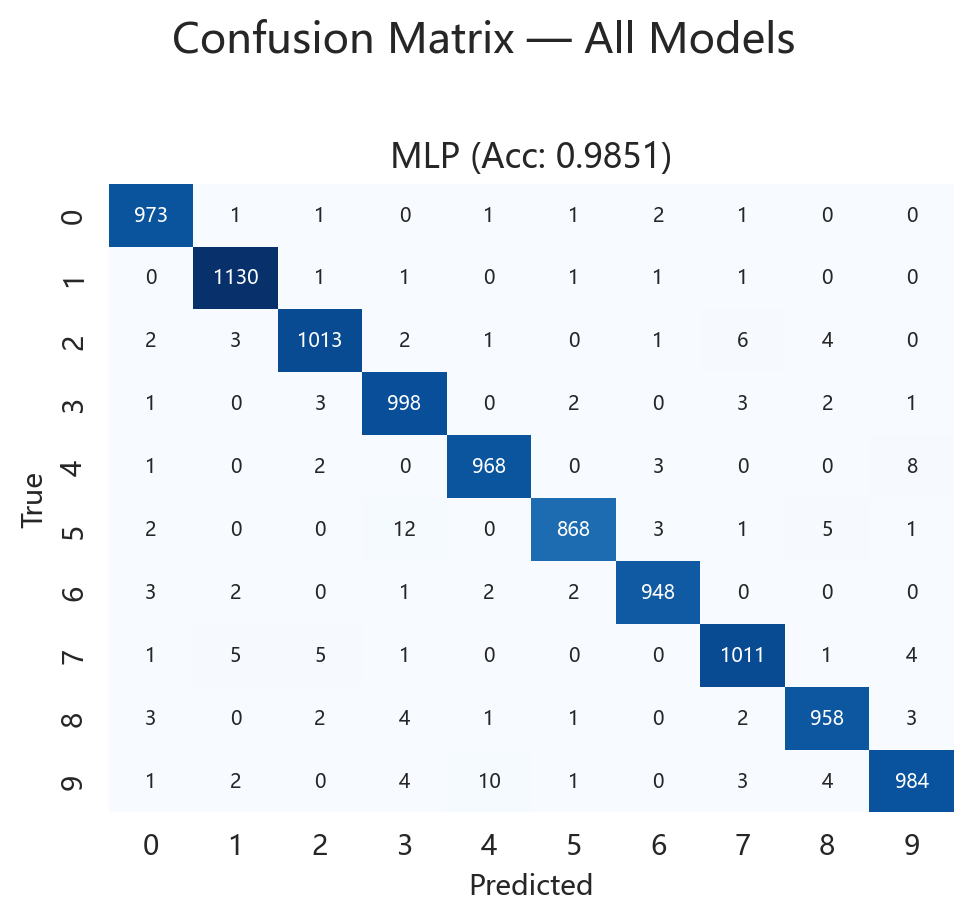

In [8]:
# [4. 混淆矩阵] seaborn heatmap | 行=真实 列=预测 | 对角线=正确分类 | 自适应子图布局
n_models = len(loaded_models)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (key, model) in enumerate(loaded_models.items()):
    cfg = MODEL_CONFIG[key]
    r = eval_results[key]
    cm = confusion_matrix(r['labels'], r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10),
                ax=axes[idx], cbar=False, annot_kws={'size': 7})
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_title(f"{cfg['name']} (Acc: {r['acc']:.4f})")

# 隐藏多余的空白子图
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrix — All Models', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 5. 错误样本可视化

> 随机抽取 10 个分类错误的样本，观察模型"看走眼"的原因。

### 为什么看错误样本？

只看准确率是不够的——98% 的准确率也意味着每 50 个样本就有一个错误。分析错误样本可以帮你：
- 发现数据标注问题（人工也可能认错）
- 理解模型的"盲区"（哪些数字容易混淆）
- 指导后续改进方向（增加数据？调整结构？）

各模型错误样本数:
  MLP     :   149 <— 当前


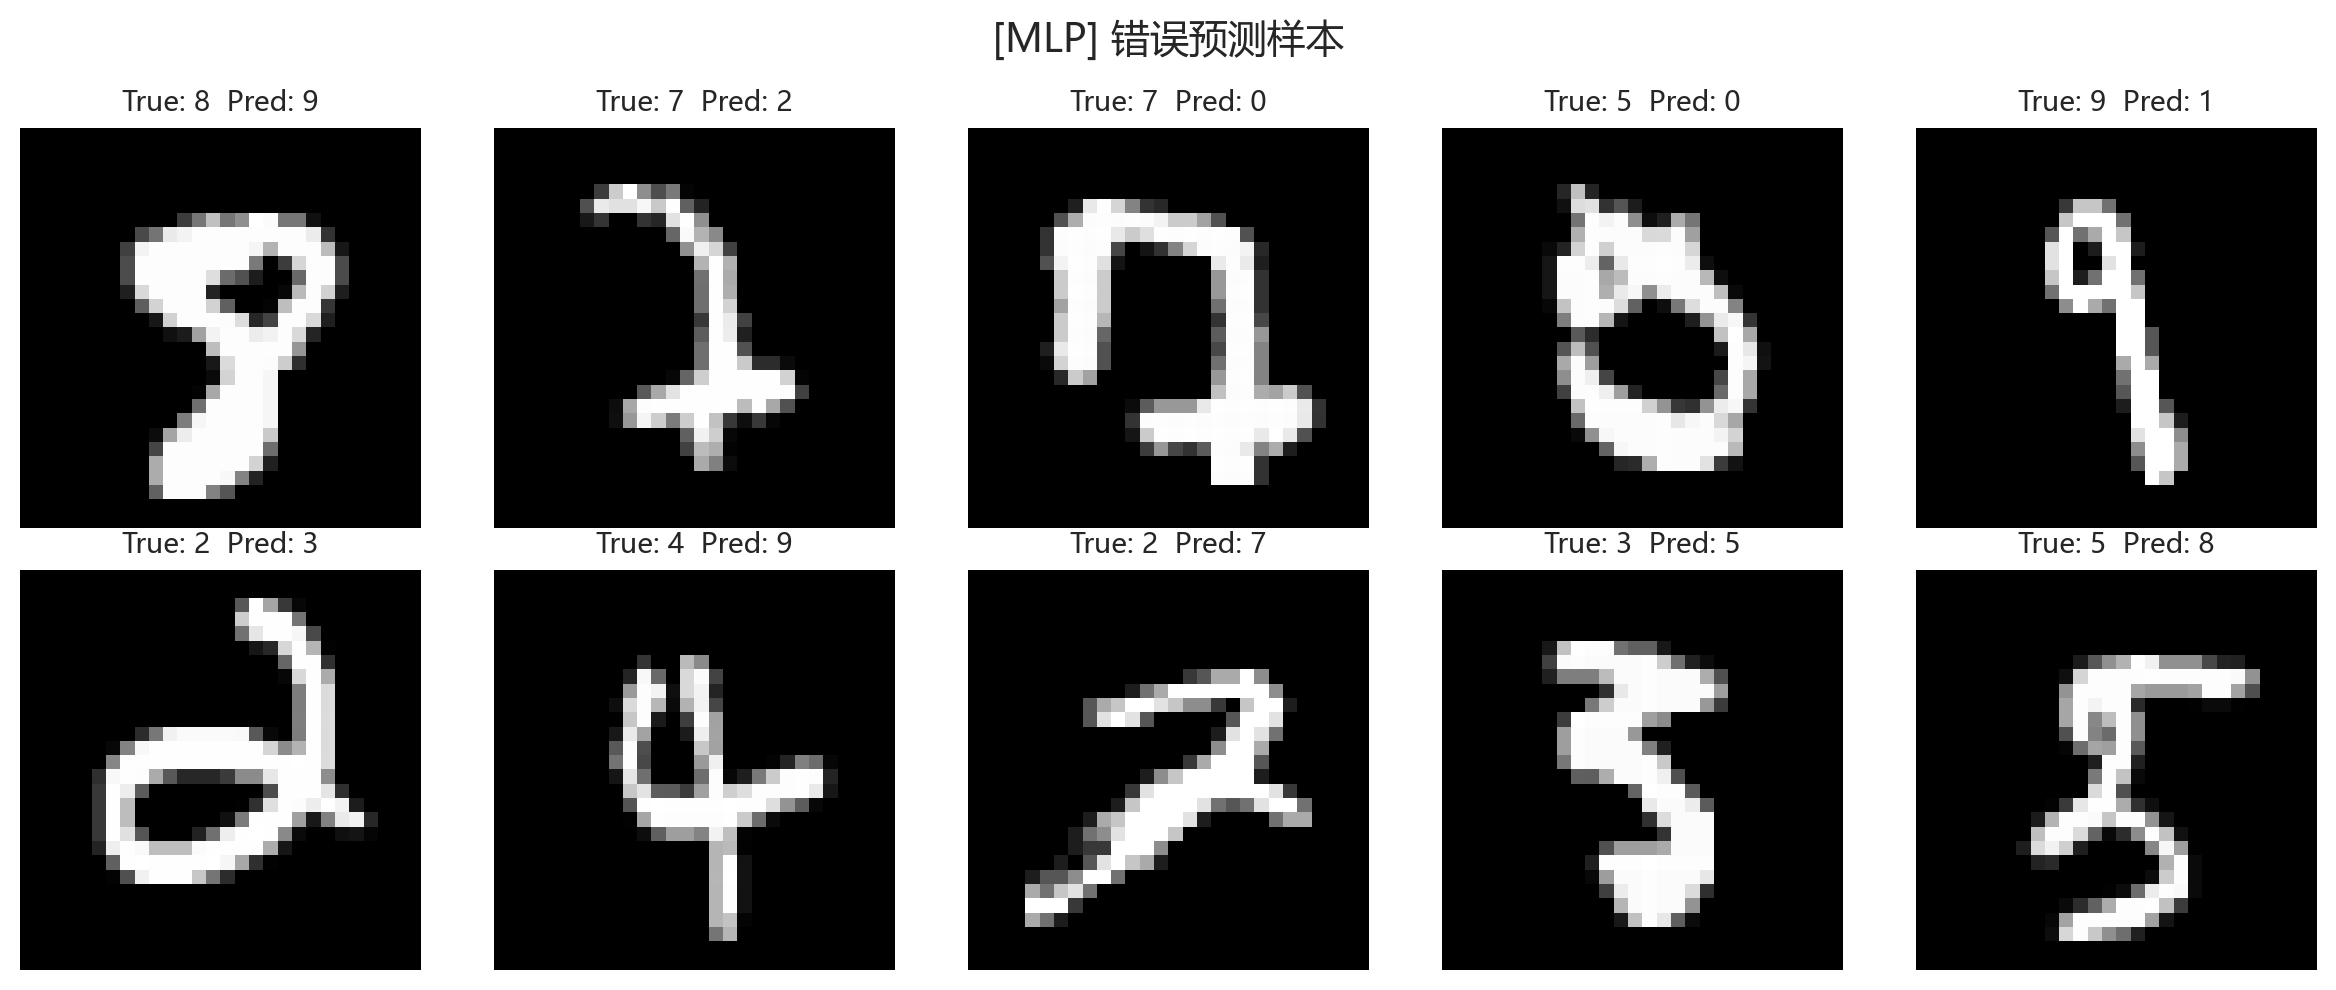

In [9]:
# [5. 错误样本] 切换 target_key 查看不同模型 | 随机抽取10个错误样本 | True vs Pred 对比
target_key = list(loaded_models.keys())[0]  # 默认第一个
# 切换模型：target_key = 'cnn'   # 可选: mlp, cnn, resnet, vit, lstm

r = eval_results[target_key]

print('各模型错误样本数:')
for key in loaded_models:
    cfg = MODEL_CONFIG[key]
    err_count = (eval_results[key]['preds'] != eval_results[key]['labels']).sum()
    marker = ' <— 当前' if key == target_key else ''
    print(f"  {cfg['name']:<8s}: {err_count:>5d}{marker}")

error_idx = np.where(r['preds'] != r['labels'])[0]

np.random.seed(42)
show_idx = np.random.choice(error_idx, min(10, len(error_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i, idx in enumerate(show_idx):
    axes[i].imshow(X_test[idx], cmap='gray')
    axes[i].set_title(f"True: {r['labels'][idx]}  Pred: {r['preds'][idx]}", fontsize=10)
    axes[i].axis('off')
for j in range(i + 1, 10):
    axes[j].axis('off')

target_name = MODEL_CONFIG[target_key]['name']
plt.suptitle(f'[{target_name}] 错误预测样本', fontsize=14)
plt.tight_layout()
plt.show()

---

## 6. 进一步学习

- 运行 `04_predict_custom.ipynb` 用自己的手写数字测试模型
- 修改模型结构，观察准确率变化
- 学习 `09_knowledge_distillation.ipynb` 用大模型教小模型